Part 4: advanced model 
In this part, we implement an advanced Fake News predictor. For this approach, we replace the MultinomialNB (Naive Bayes) from the simple model with the Multi-layer Perceptron (MLP) classifier.

First, we get the necessary imports.

Re-using from the Part 3:

In [11]:
from pathlib import Path
import re
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

#Adding import for MLP

from sklearn.neural_network import MLPClassifier

Loading the paths:

In [12]:

# Paths loading
if Path("data").exists():
    PROJECT_ROOT = Path(".")
elif Path("..").joinpath("data").exists():
    PROJECT_ROOT = Path("..")


PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

train_path = PROCESSED_DIR / "train.csv"
val_path = PROCESSED_DIR / "val.csv"
test_path = PROCESSED_DIR / "test.csv"



Loading splits files:

In [ ]:
# Load splits files
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Limiting size of the data for performance
train_df = train_df.sample(n=10000, random_state=42)
val_df = val_df.sample(n=2000, random_state=42)
test_df = test_df.sample(n=2000, random_state=42)

print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

required_cols = ["content", "type"]
for c in required_cols:
    if c not in train_df.columns:
        raise ValueError(f"Missing required column: {c}")

Train: 10,000
Val  : 2,000
Test : 2,000


Controlling the rows to load and performing training and validation

In [14]:
# Controlling the rows to load and performing training and validation
MAX_TRAIN_ROWS = 120_000
MAX_VAL_ROWS = 30_000
MAX_TEST_ROWS = 30_000

if MAX_TRAIN_ROWS is not None and len(train_df) > MAX_TRAIN_ROWS:
    train_df = train_df.sample(MAX_TRAIN_ROWS, random_state=42)
if MAX_VAL_ROWS is not None and len(val_df) > MAX_VAL_ROWS:
    val_df = val_df.sample(MAX_VAL_ROWS, random_state=42)
if MAX_TEST_ROWS is not None and len(test_df) > MAX_TEST_ROWS:
    test_df = test_df.sample(MAX_TEST_ROWS, random_state=42)

print("Rows used for this run:")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")


Rows used for this run:
Train: 10,000
Val  : 2,000
Test : 2,000


Mapping the labels:

In [15]:
# Label mapping
# Real is set to 0, Fake is set to 1
real_labels = ["reliable", "political", "unbiased"]
fake_labels = ["fake", "bias", "rumor", "hate", "unreliable", "clickbait", "conspiracy", "satire", "junksci"]

def map_binary(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["type"] = out["type"].astype(str).str.lower().str.strip()
    keep = set(real_labels + fake_labels)
    out = out[out["type"].isin(keep)].copy()
    out["label"] = out["type"].apply(lambda x: 1 if x in fake_labels else 0).astype(int)
    out["content"] = out["content"].fillna("").astype(str)
    out = out[out["content"].str.len() > 0]
    return out


train_df = map_binary(train_df)
val_df = map_binary(val_df)
test_df = map_binary(test_df)

print("Rows after filtering/mapping:")
print(f"Train: {len(train_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

print("\nTrain label balance (0=Real, 1=Fake):")
print(train_df["label"].value_counts(normalize=True))

Rows after filtering/mapping:
Train: 9,758
Val  : 1,950
Test : 1,954

Train label balance (0=Real, 1=Fake):
label
1    0.651158
0    0.348842
Name: proportion, dtype: float64


Preprocessing the text, adding functions for showing results using metrics and confusion matrix

In [ ]:
# NLTK resources setup and preprocessing to clear text like lower case, remove digits, remove punctuation, remove stop words, lemmatize
# Then added some functions to show results and confusion matrix
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if w not in stop_words]
    words = [lemmatizer.lemmatize(w, pos="v") for w in words]
    return " ".join(words)


def evaluate_model(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }


def show_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Real", "Fake"])
    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()



Turning the articles into TF-IDF feature vectors:

In [ ]:

# Articles are preprocessed and converted into TF-IDF feature vectors (up to 100,000 features).
X_train_clean = train_df["content"].apply(preprocess_text)
X_val_clean = val_df["content"].apply(preprocess_text)
X_test_clean = test_df["content"].apply(preprocess_text)

# Simple tuning
# - use unigrams+bigrams
# - slightly higher feature cap
# - sublinear tf scaling
vectorizer = TfidfVectorizer(
    analyzer="word",
    ngram_range=(1, 2),
    min_df=2,
    max_features=100_000,
    sublinear_tf=True,
)

X_train_text = vectorizer.fit_transform(X_train_clean)
X_val_text = vectorizer.transform(X_val_clean)
X_test_text = vectorizer.transform(X_test_clean)

y_train = train_df["label"].values
y_val = val_df["label"].values
y_test = test_df["label"].values

print("Text feature matrix shapes:")
print("Train:", X_train_text.shape)
print("Val  :", X_val_text.shape)
print("Test :", X_test_text.shape)


Text feature matrix shapes:
Train: (9758, 100000)
Val  : (1950, 100000)
Test : (1954, 100000)


Advanced TF-IDF + MLP

Initializing and training the model, then applying validation set:

In [28]:
# MLP model (advanced predictor)
# Small hyperparameter based search for hidden layer sizes on validation set (baseline consistency, fair comparison)

mlp_configs = [{"hidden_layer_sizes": (100,), "max_iter": 50}, {"hidden_layer_sizes": (50, 50), "max_iter": 50}]
val_rows = []

best_config = None
best_acc = -1
best_model = None
best_val_pred = None

for config in mlp_configs:
    model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        max_iter=config["max_iter"],
        random_state=42)
    model.fit(X_train_text, y_train)
    pred = model.predict(X_val_text)
    m = evaluate_model(f"MLP {config} - val", y_val, pred)
    m["config"] = str(config)
    val_rows.append(m)

    if m["accuracy"] > best_acc:
        best_acc = m["accuracy"]
        best_config = config
        best_model = model
        best_val_pred = pred
        
mlp_model = best_model
val_pred_mlp = best_val_pred

# Results (Same style as NB for consistency)
val_results = pd.DataFrame(val_rows).sort_values("accuracy", ascending=False)

print(f"Best MLP config on validation: {best_config}")

print(f"Accuracy: {best_acc:.4f}")
print(classification_report(y_val, val_pred_mlp, target_names=["Real", "Fake"], zero_division=0))

val_results

Best MLP config on validation: {'hidden_layer_sizes': (50, 50), 'max_iter': 50}
Accuracy: 0.8379
              precision    recall  f1-score   support

        Real       0.79      0.71      0.75       663
        Fake       0.86      0.91      0.88      1287

    accuracy                           0.84      1950
   macro avg       0.83      0.81      0.81      1950
weighted avg       0.84      0.84      0.84      1950



,model,accuracy,precision,recall,f1,config
1,"MLP {'hidden_layer_sizes': (50, 50), 'max_iter...",0.837949,0.856723,0.905983,0.880665,"{'hidden_layer_sizes': (50, 50), 'max_iter': 50}"
0,"MLP {'hidden_layer_sizes': (100,), 'max_iter':...",0.834359,0.853372,0.904429,0.878159,"{'hidden_layer_sizes': (100,), 'max_iter': 50}"


Confusion matrix:

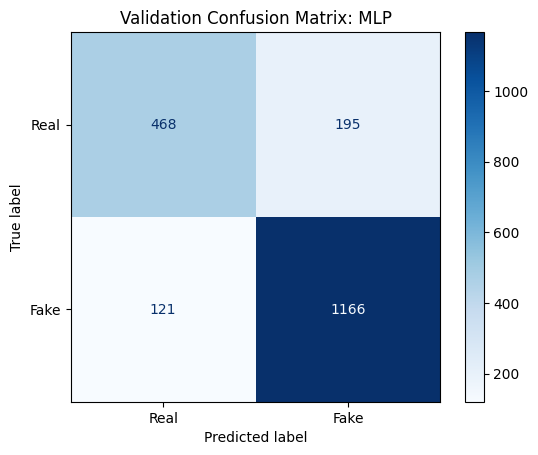

In [29]:
show_confusion(y_val, val_pred_mlp, "Validation Confusion Matrix: MLP")

Test set:

In [30]:
print(f"Final model: MLP)")


test_pred = mlp_model.predict(X_test_text)
test_metrics = evaluate_model("MLP - test", y_test, test_pred)

print("Test Metrics:")
print(f"Accuracy: {test_metrics['accuracy']:.4f}")
print(classification_report(y_test, test_pred, target_names=["Real", "Fake"], zero_division=0))

pd.DataFrame([test_metrics])

Final model: MLP)
Test Metrics:
Accuracy: 0.8383
              precision    recall  f1-score   support

        Real       0.81      0.71      0.75       685
        Fake       0.85      0.91      0.88      1269

    accuracy                           0.84      1954
   macro avg       0.83      0.81      0.82      1954
weighted avg       0.84      0.84      0.84      1954



,model,accuracy,precision,recall,f1
0,MLP - test,0.83828,0.85218,0.908589,0.879481


Confusion matrix:

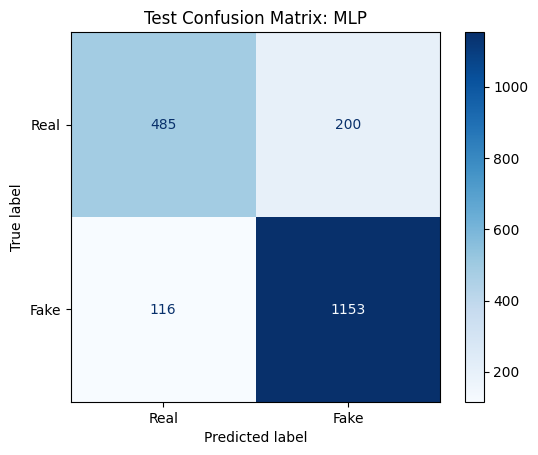

In [31]:
show_confusion(y_test, test_pred, "Test Confusion Matrix: MLP")